In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
import matplotlib.pyplot as plt
import math, os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from typing import Tuple, List, Optional
import torch.optim as optim
import matplotlib.pyplot as plt
from typing import List, TypeVar, Any
from torch.autograd import grad
Tensor = TypeVar('torch.tensor')

In [2]:
EPS = 1e-8
class DummyUAVDataset(Dataset):
    def __init__(self, window_size=30, step_size=3, batch_size=8, mode='1-hover', phase='2_6'):
        self.window_size = window_size

        base_data_path = os.path.join(os.getcwd(), '..', '..', 'data', 'Dpro', mode)
        columns = ['gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'accelerometer_m_s2[0]','accelerometer_m_s2[1]', 'accelerometer_m_s2[2]']
        # columns = ['gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]', 'magnetometer_ga[0]', 'magnetometer_ga[1]', 'magnetometer_ga[2]']
        sim_data = pd.read_csv(base_data_path + f'/all_sycn_sim_data_mode{phase}.csv', usecols=columns).to_numpy()
        raw_data = pd.read_csv(base_data_path + f'/all_sycn_raw_data_mode{phase}.csv', usecols=columns).to_numpy()
        err_data = pd.read_csv(base_data_path + f'/all_sycn_err_data_mode{phase}.csv', usecols=columns).to_numpy()
        # print(f'sim_data:{sim_data.shape} raw_data:{raw_data.shape} err_data:{err_data.shape}')

        self.dataset_x  = self.data_to_model(data=sim_data, sequence_length=window_size, step_size=step_size)
        self.dataset_y  = self.data_to_model(data=raw_data, sequence_length=window_size, step_size=step_size)
        self.dataset_e = self.data_to_model(data=err_data, sequence_length=window_size, step_size=step_size)
        print(f'dataset_x:{self.dataset_x.shape}')

        dataset = TensorDataset(self.dataset_x, self.dataset_y, self.dataset_e)
        self.dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, drop_last=True)
        
    def data_to_model(self, data, sequence_length=120, step_size=25):
        data = torch.tensor(data, dtype=float)
        sequences = []
        N = data.shape[0]
        
        for start_idx in range(0, N - sequence_length + 1, step_size):
            sequence = data[start_idx:start_idx + sequence_length]
            sequences.append(sequence)
        
        sequences = torch.stack(sequences)
        return sequences

window_size = 150
batch_size = 8
datasetuav = DummyUAVDataset(step_size=5, window_size=window_size, batch_size=batch_size, mode='1-hover', phase='2_6')

dataset_x:torch.Size([2284, 150, 6])


In [3]:
########### MDN helper funcs ###########
def parse_mdn_outputs(z, K, d):
    """
    z: [B, T, out_dim] where out_dim = K*(1 + 2*d)
    returns:
      pi:   [B, T, K]
      mu:   [B, T, K, d]
      sigma:[B, T, K, d]   (std, positive)
    """
    B, T, out_dim = z.shape
    expected = K * (1 + 2 * d)
    assert out_dim == expected, f"out_dim mismatch: got {out_dim}, expected {expected}"
    # split
    z = z.view(B, T, -1)
    pi_logits = z[..., :K]                      # [B,T,K]
    mu_flat = z[..., K: K + K * d]             # [B,T,K*d]
    sigma_flat = z[..., K + K * d:]            # [B,T,K*d]
    mu = mu_flat.view(B, T, K, d)
    sigma = sigma_flat.view(B, T, K, d)
    # mixture weights with numerical stability
    pi = F.softmax(pi_logits, dim=-1)          # [B,T,K]
    # ensure positivity & numerical stability for sigma (model outputs log-sigma or raw)
    # we treat sigma_flat as unconstrained -> apply softplus or exp
    sigma = F.softplus(sigma) + 1e-6           # [B,T,K,d], softplus is stable
    return pi, mu, sigma

def mdn_nll(pi, mu, sigma, target, reduce_mean=True):
    """
    Negative log-likelihood of target under diagonal Gaussian mixture.
    pi: [B,T,K], mu: [B,T,K,d], sigma: [B,T,K,d], target: [B,T,d]
    returns: scalar loss (mean over batch & time) if reduce_mean True, else per-sample [B,T]
    """
    B, T, K = pi.shape
    d = target.shape[-1]
    tgt = target.unsqueeze(2)                   # [B,T,1,d]
    # compute exponent term: -0.5 * sum_d ((x - mu)^2 / sigma^2)
    var_term = ((tgt - mu) / (sigma + EPS)) ** 2   # [B,T,K,d]
    exp_term = -0.5 * torch.sum(var_term, dim=-1)  # [B,T,K]
    # log sigma term: - sum_d log(sigma)
    log_sigma = - torch.sum(torch.log(sigma + EPS), dim=-1)  # [B,T,K]
    const = -0.5 * d * math.log(2 * math.pi)                 # scalar
    log_prob_components = exp_term + log_sigma + const       # [B,T,K]
    log_pi = torch.log(pi + EPS)                             # [B,T,K]
    log_weighted = log_pi + log_prob_components              # [B,T,K]
    # log-sum-exp over mixture components => log p(x)
    log_prob = torch.logsumexp(log_weighted, dim=-1)         # [B,T]
    nll = -log_prob                                           # [B,T]
    if reduce_mean:
        return torch.mean(nll)
    else:
        return nll

def mdn_sample_step(pi, mu, sigma):
    """
    Sample one step from mixture.
    pi: [B, K], mu: [B, K, d], sigma: [B, K, d]
    returns sampled tensor [B, d]
    """
    B, K, d = mu.shape
    # sample component index for each batch
    comp = torch.multinomial(pi, num_samples=1).squeeze(-1)  # [B]
    idx = comp.view(B, 1, 1).expand(-1, 1, d)               # [B,1,d]
    mu_sel = torch.gather(mu, dim=1, index=idx).squeeze(1)  # [B,d]
    sigma_sel = torch.gather(sigma, dim=1, index=idx).squeeze(1)  # [B,d]
    eps = torch.randn_like(mu_sel)
    return mu_sel + sigma_sel * eps

def mdn_conditional_mean(pi, mu):
    """
    Compute conditional expectation E[x] = sum_k pi_k * mu_k
    pi: [B,T,K], mu: [B,T,K,d] -> returns [B,T,d]
    """
    # expand & sum
    # pi[..., None] * mu -> [B,T,K,d]
    mean = torch.sum(pi.unsqueeze(-1) * mu, dim=2)  # [B,T,d]
    return mean

def mdn_mixture_covariance(pi, mu, sigma):
    """
    Compute mixture covariance per time-step:
      Cov = sum_k pi_k (Sigma_k + mu_k mu_k^T) - mu_bar mu_bar^T
    pi: [B,T,K], mu: [B,T,K,d], sigma: [B,T,K,d] (sigma is std)
    returns: cov_diag [B,T,d] (diagonal covariance across dims)
    Note: we return diagonal cov for simplicity (matches diagonal Gaussian assumption).
    """
    # convert sigma (std) to var
    var = sigma ** 2  # [B,T,K,d]
    mu_bar = mdn_conditional_mean(pi, mu)  # [B,T,d]
    # compute E[xx^T] diagonal = sum_k pi_k (var_k + mu_k^2)
    exx_diag = torch.sum(pi.unsqueeze(-1) * (var + mu ** 2), dim=2)  # [B,T,d]
    cov_diag = exx_diag - mu_bar ** 2  # [B,T,d]
    return cov_diag  # diagonal of covariance

# ------------------------------
# Generator: LSTM + FC -> MDN params (supports conditional vector c_t)
# ------------------------------
class ErrGenerator(nn.Module):
    def __init__(self, out_dim=3, cond_dim=0, hidden_size=256, num_layers=2, fc_dim=128, num_mixtures=24, act='relu'):
        """
        out_dim: d (residual dimensionality)
        cond_dim: dimensionality of conditional vector c_t (can be 0)
        The input to LSTM at time t is [E_{t-1}, c_t] as specified.
        """
        super().__init__()
        self.d = out_dim
        self.cond_dim = cond_dim
        self.inp_dim = out_dim + cond_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_mixtures = num_mixtures

        self.lstm = nn.LSTM(input_size=self.inp_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, fc_dim)
        self.fc2 = nn.Linear(fc_dim, num_mixtures * (1 + 2 * self.d))  # K*(1 + 2*d)
        if act == 'sigmoid':
            self.act = torch.sigmoid
        elif act == 'tanh':
            self.act = torch.tanh
        elif act == 'relu':
            self.act = F.relu
        else:
            self.act = lambda x: x  # identity

    def forward(self, prev_E, cond=None, hidden=None):
        """
        prev_E: tensor [B, T, d]  (these are inputs E_{t-1} aligned to outputs for next step)
        cond:   optional tensor [B, T, cond_dim] (if cond_dim>0)
        returns: pi [B,T,K], mu [B,T,K,d], sigma [B,T,K,d]
        """
        B, T, d_ = prev_E.shape
        assert d_ == self.d
        if self.cond_dim > 0:
            assert cond is not None
            assert cond.shape[0] == B and cond.shape[1] == T
            inp = torch.cat([prev_E, cond], dim=-1)  # [B,T,d+cond]
        else:
            inp = prev_E  # [B,T,d]
        out_seq, hidden = self.lstm(inp, hidden)     # out_seq: [B, T, hidden]
        z = self.act(self.fc1(out_seq))              # [B,T,fc_dim]
        z = self.fc2(z)                              # [B,T, out_dim]
        pi, mu, sigma = parse_mdn_outputs(z, self.num_mixtures, self.d)
        return pi, mu, sigma, hidden
    
    @torch.no_grad()
    def sample(self, seq_len, batch_size=1, device='cpu', start_input=None, cond_seq=None):
        """
        Autoregressive sampling:
        start_input: [B, d] or None -> used as E_0 input for first step
        cond_seq: optional [B, seq_len, cond_dim]
        returns samples [B, seq_len, d]
        """
        d = self.d
        if start_input is None:
            prev = torch.zeros(batch_size, 1, d, device=device)
        else:
            prev = start_input.view(batch_size, 1, d).to(device)
        # initialize hidden states
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size, device=device)
        hidden = (h0, c0)
        samples = []
        for t in range(seq_len):
            cond_t = None
            if self.cond_dim > 0 and cond_seq is not None:
                cond_t = cond_seq[:, t:t+1, :]  # [B,1,cond_dim]
                inp = torch.cat([prev, cond_t], dim=-1)
            else:
                inp = prev
            out_seq, hidden = self.lstm(inp, hidden)   # out_seq [B,1,hidden]
            z = self.act(self.fc1(out_seq))            # [B,1,fc_dim]
            z = self.fc2(z)                            # [B,1,out_dim]
            pi, mu, sigma = parse_mdn_outputs(z.squeeze(1).unsqueeze(1), self.num_mixtures, d)
            # pi: [B,1,K] -> squeeze to [B,K]
            pi_step = pi.squeeze(1)    # [B,K]
            mu_step = mu.squeeze(1)    # [B,K,d]
            sigma_step = sigma.squeeze(1)  # [B,K,d]
            next_x = mdn_sample_step(pi_step, mu_step, sigma_step)  # [B,d]
            samples.append(next_x.unsqueeze(1))
            prev = next_x.unsqueeze(1)
        return torch.cat(samples, dim=1)  # [B, seq_len, d]

# ------------------------------
# Discriminators (WGAN critics)
# - Time-domain critic: LSTM -> FC -> scalar
# - Frequency-domain critic: compute rFFT along time, feed real+imag sequence to LSTM -> scalar
# ------------------------------
class TimeCritic(nn.Module):
    def __init__(self, input_dim=3, hidden_size=128, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True, bidirectional=False)

        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)  # 最终输出1个logit
        self.dropout = nn.Dropout(dropout)
        self.act = F.leaky_relu 

    def forward(self, x):
        """x: [B, T, d] -> returns scores [B]"""
        out_seq, _ = self.lstm(x)   # [B,T,hidden]
        last = out_seq[:, -1, :]    # 取最后一个时间步的特征
        z = self.act(self.fc1(last))
        z = self.dropout(z)
        score = self.fc2(z).squeeze(-1)  # [B]（logits）
        return score

class FreqCritic(nn.Module):
    def __init__(self, input_dim=3, hidden_size=128, num_layers=1, use_log_mag=True, dropout=0.1):
        super().__init__()
        self.use_log_mag = use_log_mag
        # 频率特征维度：use_log_mag时为d（log幅度），否则为2*d（实部+虚部）
        self.feat_dim = input_dim if use_log_mag else 2 * input_dim
        self.lstm = nn.LSTM(input_size=self.feat_dim, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        # 新增：稳定训练的组件
        self.ln = nn.LayerNorm(self.feat_dim)
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.act = F.leaky_relu

    def forward(self, x):
        """
        x: [B, T, d]（时域序列）
        正确逻辑：
        1. 时域转频域（rfft）-> [B, T_freq, d]（复数）
        2. 特征提取：use_log_mag=True → log幅度（[B,T_freq,d]）；否则 → 实部+虚部（[B,T_freq,2d]）
        3. 归一化+LSTM+FC → logits
        """
        # 1. 时域转频域（沿时间轴dim=1）
        Xf = torch.fft.rfft(x, dim=1)  # [B, T_freq, d]（复数）
        real = Xf.real
        imag = Xf.imag

        # 2. 提取频率特征（修复核心错误）
        if self.use_log_mag:
            # 计算幅度：sqrt(real² + imag²)，加EPS避免0
            mag = torch.sqrt(real ** 2 + imag ** 2 + EPS)
            feat = torch.log(mag + EPS)  # [B, T_freq, d]（log幅度，数值更稳定）
        else:
            feat = torch.cat([real, imag], dim=-1)  # [B, T_freq, 2d]（实部+虚部）

        # 3. 归一化（关键：稳定数值范围，避免梯度爆炸）
        feat = self.ln(feat)  # [B, T_freq, feat_dim]

        # 4. LSTM+FC特征提取
        out_seq, _ = self.lstm(feat)  # [B, T_freq, hidden]
        last = out_seq[:, -1, :]      # 取最后一个频率步的特征
        z = self.act(self.fc1(last))
        z = self.dropout(z)
        score = self.fc2(z).squeeze(-1)  # [B]（logits）

        return score

def wasserstein_loss(x, recon_x, std_weight=2):
    """
    计算 Wasserstein 损失（即 Earth Mover's Distance）
    :param x: 原始输入序列, 形状为 [batch_size, seq_len, input_dim]
    :param recon_x: 重建的序列, 形状为 [batch_size, seq_len, input_dim]
    :return: Wasserstein 损失
    """
    mean_x = torch.mean(x, dim=(0, 1))  # 计算原始数据的均值 [batch_size]
    std_x = torch.std(x, dim=(0, 1))    # 计算原始数据的标准差 [batch_size]

    mean_recon_x = torch.mean(recon_x, dim=(0, 1))  # 计算重建数据的均值 [batch_size]
    std_recon_x = torch.std(recon_x, dim=(0, 1))    # 计算重建数据的标准差 [batch_size]

    # 计算 Wasserstein 距离（均值差异 + 标准差差异）
    # Wasserstein 距离是均值差异和标准差差异的组合
    loss = torch.mean(torch.abs(mean_x - mean_recon_x) + std_weight * torch.abs(std_x - std_recon_x))

    return loss 

In [4]:
# ------------------------------
# Critic (WGAN-GP) training for one epoch
# ------------------------------
def train_critics_epoch(time_critic, freq_critic, generator,
                        dataloader, opt_time, opt_freq,
                        device, lambda_recon=1.0, n_critic=5,
                        cond_dim=None):
    """
    Train both time & freq critics for one epoch over dataloader.
    For each batch, perform n_critic gradient steps for critics.
    """
    time_critic.train()
    freq_critic.train()
    total_time_loss = 0.0
    total_freq_loss = 0.0
    total_samples = 0
    criterion = nn.BCEWithLogitsLoss()

    for _, _, err in dataloader:
        real = err
        real = real.to(device, dtype=torch.float32)
        B, T, d = real.shape
        total_samples += B

        # Prepare generator inputs: teacher-forcing using real previous residuals
        # generator.forward expects prev_E: [B, T-1, d] (predict next-step)
        x_in = real[:, :-1, :]          # [B, T-1, d]
        cond_for_gen = None  # set if using conditional vectors aligned to timesteps

        # Run n_critic updates for critics using this batch
        for _ in range(n_critic):
            # Generate fake sequences (use conditional mean for stability)
            with torch.no_grad():
                pi, mu, sigma, _ = generator(x_in, cond=cond_for_gen)
                fake_mean = mdn_conditional_mean(pi, mu)   # [B, T-1, d]
                # Align fake sequence to same length T: prepend zeros (or shift)
                fake_seq = torch.cat([torch.zeros(B, 1, d, device=device), fake_mean], dim=1)  # [B,T,d]

            logits_real = time_critic(real)   # [B]
            logits_gen = time_critic(fake_seq.detach())
            # labels
            labels_real = torch.ones_like(logits_real, device=device)
            labels_gen = torch.zeros_like(logits_gen, device=device)
            loss_real = criterion(logits_real, labels_real)
            loss_gen = criterion(logits_gen, labels_gen)
            loss_time_total = 0.5 * (loss_real + loss_gen)
            loss_time_total.backward()
            opt_time.step()
            total_time_loss += loss_time_total.item() * B

            # Frequency critic update
            logits_real = freq_critic(real)   # [B]
            logits_gen = freq_critic(fake_seq.detach())
            # labels
            labels_real = torch.ones_like(logits_real, device=device)
            labels_gen = torch.zeros_like(logits_gen, device=device)
            loss_real = criterion(logits_real, labels_real)
            loss_gen = criterion(logits_gen, labels_gen)
            loss_freq_total = 0.5 * (loss_real + loss_gen)
            loss_freq_total.backward()
            opt_freq.step()
            total_freq_loss += loss_freq_total.item() * B

    avg_time_loss = total_time_loss / total_samples
    avg_freq_loss = total_freq_loss / total_samples
    return avg_time_loss, avg_freq_loss

# ------------------------------
# Generator training for one epoch
# ------------------------------
def train_generator_epoch(generator, time_critic, freq_critic, dataloader,
                          opt_G, device, lambda_recon = 1.0, lambda_mdn=1.0, lambda_wgan=1.0,
                          clip_grad=None, cond_dim=None):
    """
    Train generator over one epoch:
      Loss = lambda_mdn * MDN_NLL + lambda_wgan * WGAN_GeneratorLoss
    WGAN_GeneratorLoss = - E[ D_time(fake) ] - E[ D_freq(fake) ]
    """
    generator.train()
    total_loss = 0.0
    total_nll = 0.0
    total_wgan = 0.0
    total_recon = 0.0
    total_samples = 0

    for _, _, err in dataloader:
        real = err
        real = real.to(device, dtype=torch.float32)
        B, T, d = real.shape
        total_samples += B

        # inputs & targets for MDN (teacher forcing)
        x_in = real[:, :-1, :]       # [B, T-1, d]
        x_target = real[:, 1:, :]    # [B, T-1, d]
        cond_for_gen = None          # set if available

        # Forward generator
        pi, mu, sigma, _ = generator(x_in, cond=cond_for_gen)
        # MDN NLL computed on x_target
        nll = mdn_nll(pi, mu, sigma, x_target)  # scalar

        # Construct fake_seq for critic scoring (prepend zeros to align length)
        fake_mean = mdn_conditional_mean(pi, mu)  # [B, T-1, d]
        fake_seq = torch.cat([torch.zeros(B, 1, d, device=device), fake_mean], dim=1)  # [B, T, d]

        recon_loss = torch.mean(torch.square(real - fake_seq))  # MSE损失

        # WGAN generator loss: minimize -E[D(fake)] for both critics
        wgan_loss = wasserstein_loss(real, fake_seq)

        loss_G = lambda_mdn * nll + lambda_recon * recon_loss

        opt_G.zero_grad()
        loss_G.backward()
        if clip_grad is not None:
            torch.nn.utils.clip_grad_norm_(generator.parameters(), clip_grad)
        opt_G.step()

        total_loss += loss_G.item() * B
        total_nll += nll.item() * B
        total_wgan += wgan_loss.item() * B
        total_recon += recon_loss.item() * B

    avg_loss = total_loss / total_samples
    avg_nll = total_nll / total_samples
    avg_wgan = total_wgan / total_samples
    avg_recon = total_recon / total_samples
    return avg_loss, avg_nll, avg_wgan, avg_recon

# ------------------------------
# High-level training loop (替换 train_errCompensator)
# ------------------------------
def train_errCompensator(generator, time_critic, freq_critic, dataloader,
                         device='cpu',
                         dis_opt_time=None, dis_opt_freq=None, gen_opt=None,
                         batch_size=8,
                         dis_epochs_per_iter=200, gen_epochs_per_iter=100,
                         num_iters=10, n_critic=5, lambda_recon=1.0,
                         lambda_mdn=1.0, lambda_wgan=1.0, clip_grad=5.0):
    """
    Main training loop implementing alternating updates:
      For each iter:
        - train critics for dis_epochs_per_iter epochs (each epoch loops dataloader once)
        - train generator for gen_epochs_per_iter epochs
    Arguments:
      - generator: ErrGenerator instance
      - time_critic, freq_critic: critic networks (WGAN-GP style)
      - dataloader: DataLoader over residual sequences [N, T, d]
      - n_critic: number of critic steps per batch internal to train_critics_epoch
      - lambda_* : weights for loss terms
    """
    if dis_opt_time is None:
        dis_opt_time = optim.Adam(time_critic.parameters(), lr=1e-4, betas=(0.5, 0.9))
    if dis_opt_freq is None:
        dis_opt_freq = optim.Adam(freq_critic.parameters(), lr=1e-4, betas=(0.5, 0.9))
    if gen_opt is None:
        gen_opt = optim.RMSprop(generator.parameters(), lr=1e-4)

    # set device
    generator.to(device)
    time_critic.to(device)
    freq_critic.to(device)
    loss_records = {
        'total_loss': [], 
        'time_loss': [],
        'freq_loss': [],
        'nll_loss': [],    
        'wgan_loss': [],
        'recon_loss': [] 
    }

    for it in range(num_iters):
        print(f"=== Iter {it+1}/{num_iters} : train critics for {dis_epochs_per_iter} epochs ===")
        for e in range(dis_epochs_per_iter):
            avg_time_loss, avg_freq_loss = train_critics_epoch(
                time_critic, freq_critic, generator,
                dataloader, dis_opt_time, dis_opt_freq,
                device, lambda_recon=lambda_recon, n_critic=n_critic
            )
            if (e+1) % 50 == 0 or e == 0:
                print(f"  Critic epoch {e+1}/{dis_epochs_per_iter}, time_loss={avg_time_loss:.6f}, freq_loss={avg_freq_loss:.6f}")

        loss_records['time_loss'].append(avg_time_loss)
        loss_records['freq_loss'].append(avg_freq_loss)

        print(f"=== Iter {it+1}/{num_iters} : train generator for {gen_epochs_per_iter} epochs ===")
        for e in range(gen_epochs_per_iter):
            avg_loss, avg_nll, avg_wgan, avg_recon = train_generator_epoch(
                generator, time_critic, freq_critic, dataloader,
                gen_opt, device, lambda_recon = lambda_recon, lambda_mdn=lambda_mdn, lambda_wgan=lambda_wgan, 
                clip_grad=clip_grad
            )
            if (e+1) % 25 == 0 or e == 0:
                print(f"  G epoch {e+1}/{gen_epochs_per_iter}, total_loss={avg_loss:.6f}, nll={avg_nll:.6f}, wgan={avg_wgan:.6f} , recon={avg_recon:.6f}")

        loss_records['total_loss'].append(avg_loss)
        loss_records['nll_loss'].append(avg_nll)
        loss_records['wgan_loss'].append(avg_wgan) 
        loss_records['recon_loss'].append(avg_recon)  

    return generator, time_critic, freq_critic, loss_records



In [5]:
# --- instantiate models ---
dataloader = datasetuav.dataloader
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen = ErrGenerator(out_dim=6, cond_dim=0, hidden_size=256, num_layers=2, fc_dim=128, num_mixtures=24).to(device)
time_critic = TimeCritic(input_dim=6, hidden_size=128, num_layers=1).to(device)
freq_critic = FreqCritic(input_dim=6, hidden_size=128, num_layers=1).to(device)

# --- optimizers ---
dis_opt_time = torch.optim.Adam(time_critic.parameters(), lr=1e-4, betas=(0.5,0.9))
dis_opt_freq = torch.optim.Adam(freq_critic.parameters(), lr=1e-5, betas=(0.5,0.9))
gen_opt = torch.optim.RMSprop(gen.parameters(), lr=1e-3)  # paper used RMSProp for G

In [6]:
# --- run training (uses the train_errCompensator implementation provided earlier) ---
gen, time_critic, freq_critic, loss_records = train_errCompensator(
    generator=gen,
    time_critic=time_critic,
    freq_critic=freq_critic,
    dataloader=dataloader,
    device=device,
    dis_opt_time=dis_opt_time,
    dis_opt_freq=dis_opt_freq,
    gen_opt=gen_opt,
    batch_size=8,
    dis_epochs_per_iter=3,    # you set small values for quick runs
    gen_epochs_per_iter=2,
    num_iters=80,
    n_critic=3,
    lambda_recon=1.0,
    lambda_mdn=1.0,
    lambda_wgan=0.75,
    clip_grad=None
)

=== Iter 1/80 : train critics for 3 epochs ===
  Critic epoch 1/3, time_loss=2.607421, freq_loss=1.861923
=== Iter 1/80 : train generator for 2 epochs ===
  G epoch 1/2, total_loss=-2.123376, nll=-2.185593, wgan=0.375904 , recon=0.062217
=== Iter 2/80 : train critics for 3 epochs ===
  Critic epoch 1/3, time_loss=3.882082, freq_loss=2.083737
=== Iter 2/80 : train generator for 2 epochs ===
  G epoch 1/2, total_loss=-5.838393, nll=-5.864932, wgan=0.177346 , recon=0.026540
=== Iter 3/80 : train critics for 3 epochs ===
  Critic epoch 1/3, time_loss=1.836579, freq_loss=2.383225
=== Iter 3/80 : train generator for 2 epochs ===
  G epoch 1/2, total_loss=-7.779450, nll=-7.795862, wgan=0.086603 , recon=0.016412
=== Iter 4/80 : train critics for 3 epochs ===
  Critic epoch 1/3, time_loss=2.347979, freq_loss=2.352312
=== Iter 4/80 : train generator for 2 epochs ===
  G epoch 1/2, total_loss=-8.416686, nll=-8.431486, wgan=0.073942 , recon=0.014800
=== Iter 5/80 : train critics for 3 epochs ===
 

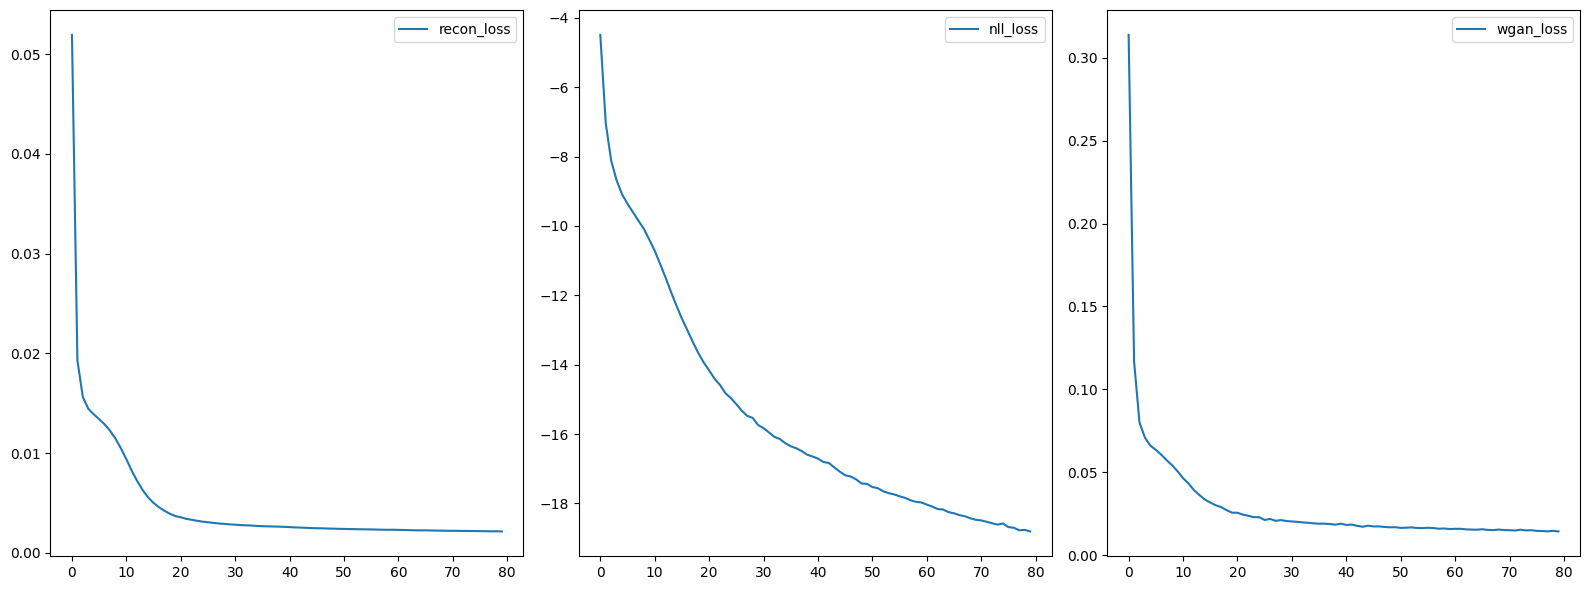

In [7]:
plt.figure(figsize=(16, 6))
plt.subplot(1, 3, 1)
plt.plot(loss_records['recon_loss'], label="recon_loss")
plt.legend()
plt.subplot(1, 3, 2)
plt.plot(loss_records['nll_loss'], label="nll_loss")
plt.legend()
plt.subplot(1, 3, 3)
plt.plot(loss_records['wgan_loss'], label="wgan_loss")
plt.legend()
plt.tight_layout()
plt.show()

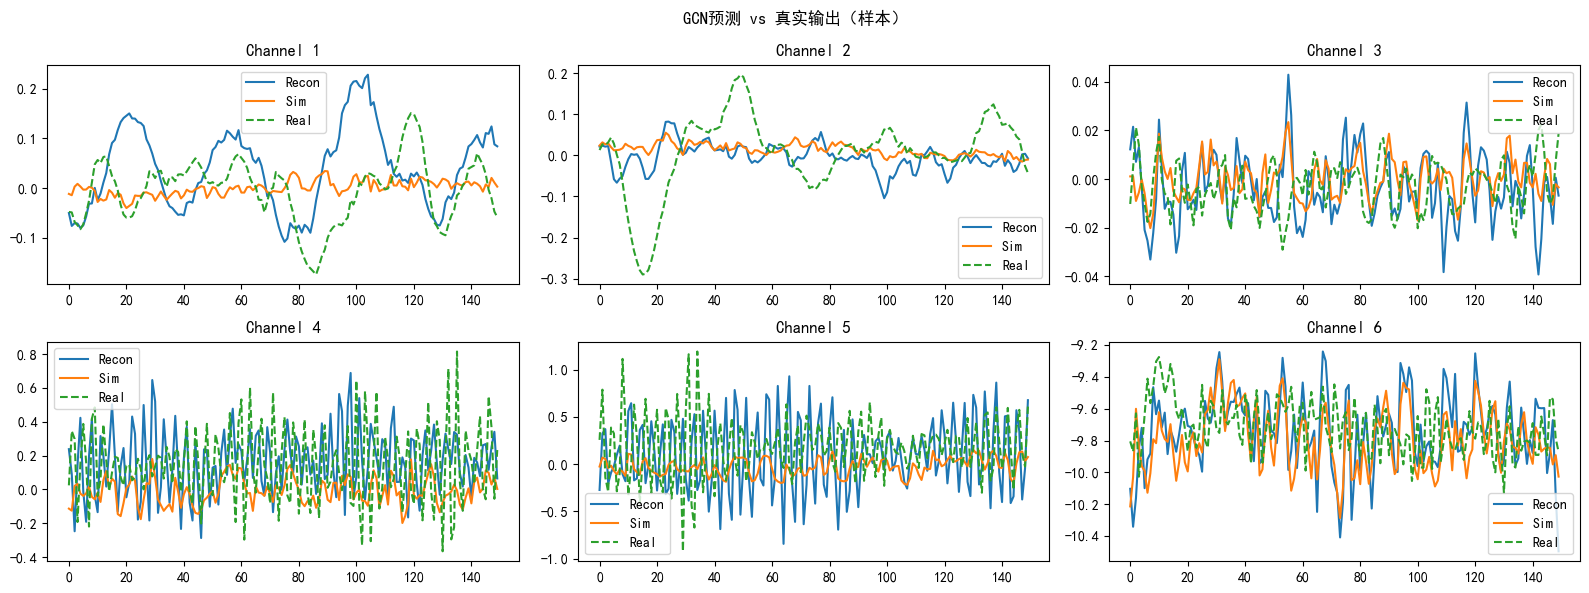

✅ 测试集评估指标:
    MSE: 0.096590
    MAE: 0.187382
    RMSE: 0.309710
    R² Score: -0.889559
    Wasserstein Distance: 0.052493


In [16]:
from scipy.stats import wasserstein_distance

def calculate_wasserstein_distance(pred, true):
    """计算Wasserstein距离（Earth Mover's Distance）"""
    wasserstein_dist = 0
    D = pred.shape[1]  # 特征数
    
    for d in range(D):
        pred_data = pred[:, d].cpu().numpy()
        true_data = true[:, d].cpu().numpy()
        # 计算单特征的Wasserstein距离
        wasserstein_dist += wasserstein_distance(pred_data, true_data)
    
    return wasserstein_dist / D  # 返回所有特征的平均距离

def evaluate(model, test_loader, device, look_id=4):
    model.eval()
    metrics = {
        'mse': 0.0,
        'mae': 0.0,
        'rmse': 0.0,
        'r2': 0.0,
        'wasserstein': 0.0,
    }
    count = 0
    predictions = []
    true_data = []
    origin_sim = []
    with torch.no_grad():
        for xb, yb, eb in test_loader:
            gen = model.sample(seq_len=150, batch_size=batch_size, device=device)
            # print(f'gen shape:{gen.shape} yb shape:{yb.shape}')

            h = xb.view(xb.size(0), -1, 6).to(device)
            raw = yb.view(yb.size(0), -1, 6).to(device)

            pred_err = gen.view(gen.size(0), -1, 6).to(device) 
            target_err = eb.view(eb.size(0), -1, 6).to(device)
            predictions.append(pred_err)

            # 计算单批次指标（按样本和特征平均）
            B, W, F_in = pred_err.shape
            pred_flat = pred_err.view(-1, F_in)  # [B*W, F]
            true_flat = eb.view(-1, F_in).to(device)  # [B*W, F]
            # print(f'pred_flat device:{pred_flat.device} true_flat device:{true_flat.device}')

            predictions.append(xb.to(device) - pred_err)
            true_data.append(yb.to(device))
            origin_sim.append(xb.to(device))
            # 基本误差指标
            metrics['mse'] += F.mse_loss(pred_flat, true_flat).item()
            metrics['mae'] += F.l1_loss(pred_flat, true_flat).item()
            metrics['rmse'] += torch.sqrt(F.mse_loss(pred_flat, true_flat)).item()
            
            # R²（决定系数）
            ss_total = torch.sum((true_flat - true_flat.mean(dim=0)) **2, dim=0)  # 总变异
            ss_resid = torch.sum((true_flat - pred_flat)** 2, dim=0)  # 残差变异
            r2 = torch.mean(1 - ss_resid / (ss_total + 1e-6)).item()  # 平均所有特征的R²
            metrics['r2'] += r2

            # 分布特征指标
            metrics['wasserstein'] += calculate_wasserstein_distance(pred_flat, true_flat)

            count += 1

            # 可视化指定样本
            if count == look_id:
                pred_np = pred_err[0].detach().cpu().numpy()     # [W, 9]
                real_np = raw[0].detach().cpu().numpy()   # [W, 9]
                sim_np = h[0].detach().cpu().numpy()              # [W, 10]
                recon_np = sim_np - pred_np

                plt.figure(figsize=(16, 6))
                for i in range(6):  # 可选展示前三个通道
                    plt.subplot(2, 3, i+1)
                    plt.plot(recon_np[:, i], label="Recon")
                    plt.plot(sim_np[:, i], label="Sim")
                    plt.plot(real_np[:, i], label="Real", linestyle='--')
                    plt.title(f'Channel {i+1}')
                    plt.legend()
                plt.suptitle("GCN预测 vs 真实输出（样本）")
                plt.tight_layout()
                plt.show()

    compensated_dataset_x = torch.cat(predictions, dim=0)
    raw_dataset_y = torch.cat(true_data, dim=0)
    origin_dataset_x = torch.cat(origin_sim, dim=0)

    for key in metrics:
        metrics[key] /= count

    print(f"✅ 测试集评估指标:")
    print(f"    MSE: {metrics['mse']:.6f}")
    print(f"    MAE: {metrics['mae']:.6f}")
    print(f"    RMSE: {metrics['rmse']:.6f}")
    print(f"    R² Score: {metrics['r2']:.6f}")
    print(f"    Wasserstein Distance: {metrics['wasserstein']:.6f}")

    return compensated_dataset_x, raw_dataset_y, origin_dataset_x

dataloader = datasetuav.dataloader
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]
plt.rcParams["axes.unicode_minus"] = False

compensated_dataset_x, raw_dataset_y, origin_dataset_x = evaluate(gen, dataloader, device = 'cuda' if torch.cuda.is_available() else 'cpu', look_id=1)

recovered_sim_data shape: (22945, 6) recovered_raw_data shape: (11545, 6)


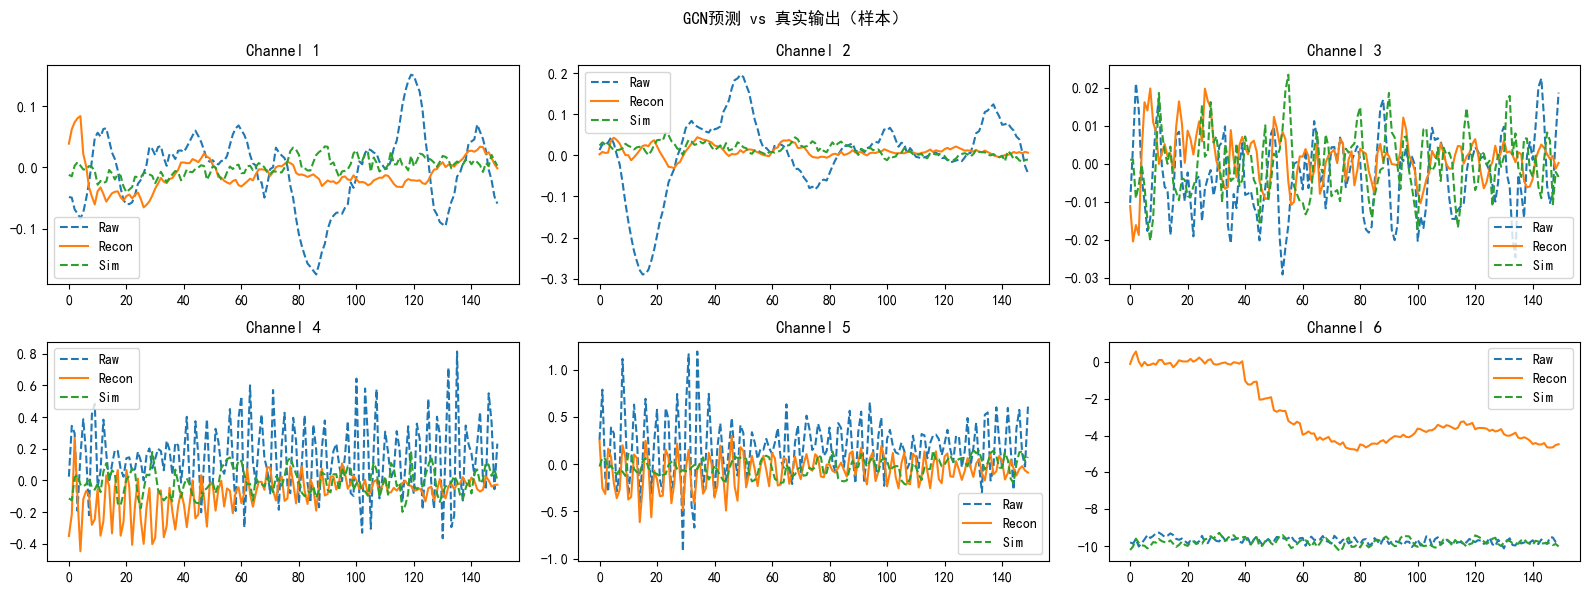

In [18]:
def reverse_data_to_model(compensated_dataset_x, sequence_length, step_size):
    compensated_dataset_x = compensated_dataset_x.cpu().numpy() 
    num_sequences, W, feature_num = compensated_dataset_x.shape  
    
    original_length = (num_sequences - 1) * step_size + sequence_length
    
    recovered_data = np.zeros((original_length, feature_num), dtype=np.float32)
    counts = np.zeros((original_length, feature_num), dtype=np.float32)  
    
    for seq_idx in range(num_sequences):
        start_idx = seq_idx * step_size  
        end_idx = start_idx + sequence_length
        seq = compensated_dataset_x[seq_idx]
        
        recovered_data[start_idx:end_idx] += seq
        counts[start_idx:end_idx] += 1
    
    # 5. 核心修改：仅重叠部分（counts > 1）除以计数，无重叠部分（counts == 1）不操作
    # counts == 0：未被任何序列覆盖，保持0；counts == 1：无重叠，保留累加值；counts > 1：重叠，取平均
    mask_overlap = counts > 1  # 重叠位置的掩码（True表示重叠）
    recovered_data[mask_overlap] = recovered_data[mask_overlap] / counts[mask_overlap]

    return recovered_data

def reconstruct_from_sequences(sequences, step_size, sequence_length):
    """
    sequences: torch.Tensor or np.ndarray with shape (S, L, F)
    step_size: int
    sequence_length: int (L)
    返回：reconstructed numpy array shape (N_rec, F)
    """
    # ensure numpy
    if isinstance(sequences, torch.Tensor):
        seq = sequences.detach().cpu().numpy()
    else:
        seq = np.asarray(sequences)

    S, L, F = seq.shape
    assert L == sequence_length, f"Provided sequence_length {sequence_length} doesn't match sequences.shape[1] {L}"

    # length of reconstructed series (matches forward: last_start = (S-1)*step)
    N_rec = (S - 1) * step_size + sequence_length

    accum = np.zeros((N_rec, F), dtype=seq.dtype)
    counts = np.zeros((N_rec, F), dtype=np.int32)

    for i in range(S):
        start = i * step_size
        end = start + sequence_length
        accum[start:end, :] += seq[i]
        counts[start:end, :] += 1

    # sanity: no zero counts should remain in the used region
    if np.any(counts == 0):
        # 只有在非常异常的情况下会出现（理论上不会），但我们防护一下
        zero_idx = np.where(counts == 0)
        raise RuntimeError(f"Found zero-contribution positions in reconstruction at indices: {zero_idx}")

    reconstructed = accum / counts.astype(accum.dtype)
    return reconstructed

# recovered_sim_data = reverse_data_to_model(
#     compensated_dataset_x=compensated_dataset_x,
#     sequence_length=window_size,
#     step_size=5
# ) 

recovered_sim_data = reconstruct_from_sequences(
    sequences=compensated_dataset_x,
    sequence_length=window_size,
    step_size=5
) 

# recovered_raw_data = reverse_data_to_model(
#     compensated_dataset_x=raw_dataset_y,
#     sequence_length=window_size,
#     step_size=5
# )

recovered_raw_data = reconstruct_from_sequences(
    sequences=raw_dataset_y,
    sequence_length=window_size,
    step_size=5
)

# recovered_raw_sim_data = reverse_data_to_model(
#     compensated_dataset_x=origin_dataset_x,
#     sequence_length=window_size,
#     step_size=5
# )

recovered_raw_sim_data = reconstruct_from_sequences(
    sequences=origin_dataset_x,
    sequence_length=window_size,
    step_size=5
)

print(f'recovered_sim_data shape: {recovered_sim_data.shape} recovered_raw_data shape: {recovered_raw_data.shape}')

plt.figure(figsize=(16, 6))
length_ = 150
for i in range(recovered_sim_data.shape[1]):
    plt.subplot(2, 3, i+1)
    plt.plot(recovered_raw_data[:length_, i], label="Raw", linestyle='--')
    plt.plot(recovered_sim_data[:length_, i], label="Recon")
    plt.plot(recovered_raw_sim_data[:length_, i], label="Sim", linestyle='--')
    plt.title(f'Channel {i+1}')
    plt.legend()
plt.suptitle("GCN预测 vs 真实输出（样本）")
plt.tight_layout()
plt.show()


In [110]:
import shutil

ReSaved = True

mode_name = 'EC_TFCritic.pth'
folder_name = mode_name.split('.')[0]
folder_path = os.path.join(os.getcwd(), folder_name)
path = os.path.join(os.getcwd(), folder_name, mode_name)

if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)

torch.save(gen, path)
print(f'Model Re-Saved to {path}')


Model Re-Saved to d:\TJH\Platform\PHM\model\compare\EC_TFCritic\EC_TFCritic.pth
